In [13]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import learning_curve

In [14]:

iris = load_iris()
wine = load_wine()

def data_explore(data, name):
    print(data.data.shape)
    print(data.target.shape)
    
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    print(df.head())
    
    print(df.isnull().sum().sum())

    print(df.describe())
    print("-"*80)

data_explore(iris, "Iris")
data_explore(wine, "Wine")

(150, 4)
(150,)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
0
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000   

In [15]:
def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"X={X_train.shape}, y={y_train.shape}")
    print(f"X={X_test.shape}, y={y_test.shape}")
    return X_train, X_test, y_train, y_test

X_iris, y_iris = iris.data, iris.target
X_iris_train, X_iris_test, y_iris_train, y_iris_test = split_data(X_iris, y_iris)

X_wine, y_wine = wine.data, wine.target
X_wine_train, X_wine_test, y_wine_train, y_wine_test = split_data(X_wine, y_wine)

X=(105, 4), y=(105,)
X=(45, 4), y=(45,)
X=(124, 13), y=(124,)
X=(54, 13), y=(54,)


In [16]:
def standardize(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) 
    X_test_scaled = scaler.transform(X_test)       
    return X_train_scaled, X_test_scaled, scaler

X_iris_train_scaled, X_iris_test_scaled, _ = standardize(X_iris_train, X_iris_test)
X_wine_train_scaled, X_wine_test_scaled, _ = standardize(X_wine_train, X_wine_test)

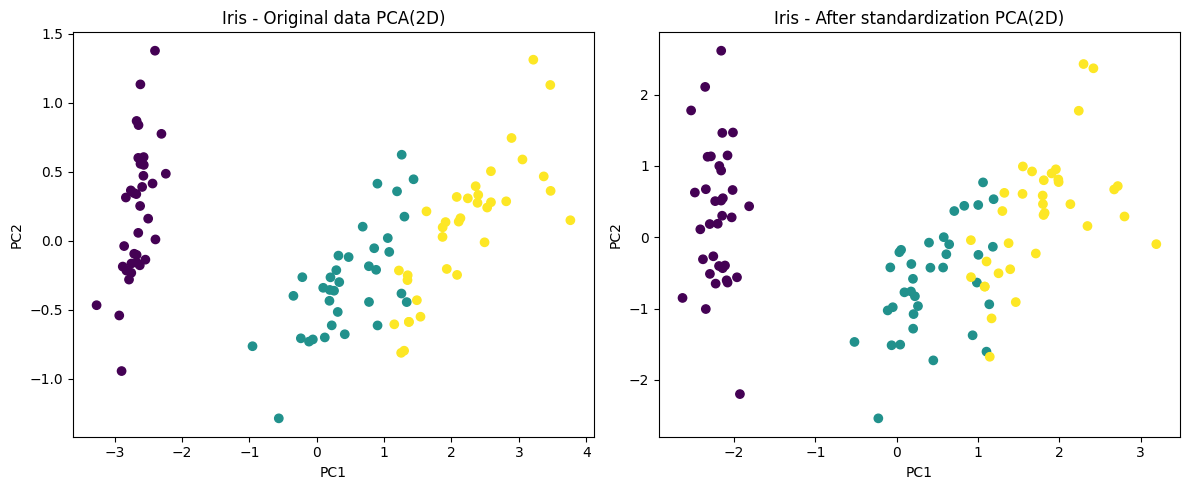

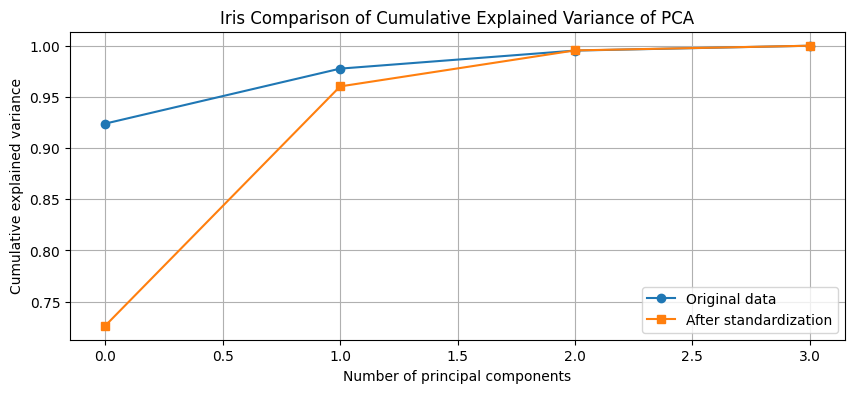

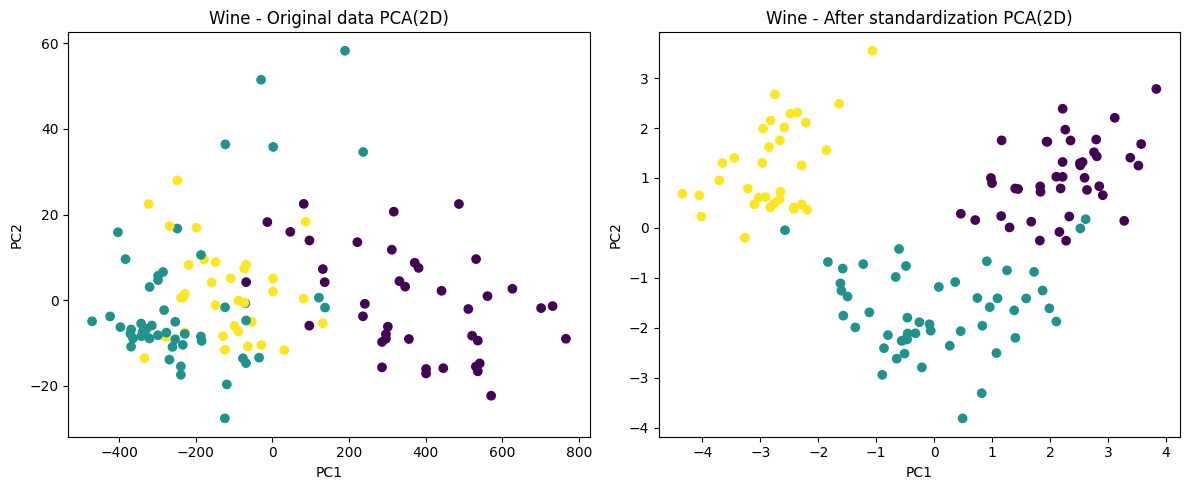

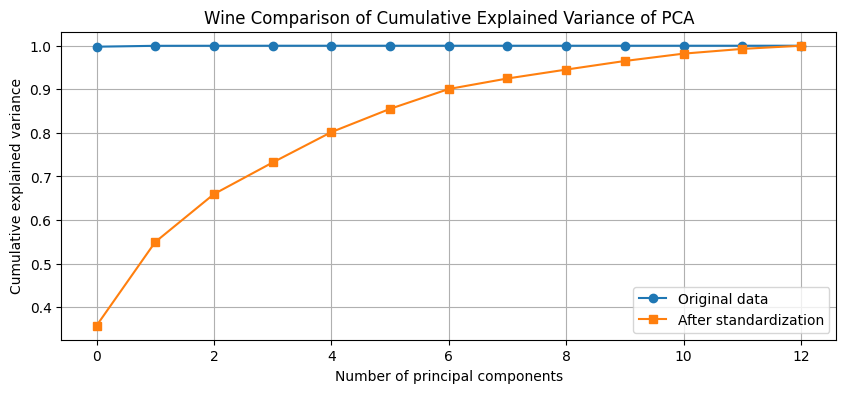

In [17]:

def pca_visualize(X_train, X_train_scaled, y_train, name):
    
    pca_raw = PCA(n_components=2)
    X_raw_pca = pca_raw.fit_transform(X_train)
    
    
    pca_scaled = PCA(n_components=2)
    X_scaled_pca = pca_scaled.fit_transform(X_train_scaled)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.scatter(X_raw_pca[:,0], X_raw_pca[:,1], c=y_train, cmap='viridis')
    plt.title(f'{name} - Original data PCA(2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    plt.subplot(1,2,2)
    plt.scatter(X_scaled_pca[:,0], X_scaled_pca[:,1], c=y_train, cmap='viridis')
    plt.title(f'{name} - After standardization PCA(2D)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()
    
    pca_full_raw = PCA().fit(X_train)
    pca_full_scaled = PCA().fit(X_train_scaled)
    
    plt.figure(figsize=(10,4))
    plt.plot(np.cumsum(pca_full_raw.explained_variance_ratio_), label='Original data', marker='o')
    plt.plot(np.cumsum(pca_full_scaled.explained_variance_ratio_), label='After standardization', marker='s')
    plt.xlabel('Number of principal components')
    plt.ylabel('Cumulative explained variance')
    plt.title(f'{name} Comparison of Cumulative Explained Variance of PCA')
    plt.legend()
    plt.grid()
    plt.show()

pca_visualize(X_iris_train, X_iris_train_scaled, y_iris_train, "Iris")
pca_visualize(X_wine_train, X_wine_train_scaled, y_wine_train, "Wine")

PCA Visualization Comparison
Original data: Features have different dimensions (e.g., the Wine dataset features vary greatly in value range), and variance is dominated by high-value features, making it impossible for PCA projection to effectively distinguish categories.
After standardization: All features have unified dimensions. PCA can capture core differences between categories, resulting in clearer clustering results.

Explained Variance Comparison
Original data: Variance is concentrated in a few principal components and dominated by high-value features.
After standardization: Variance is more evenly distributed across multiple principal components, enabling more comprehensive extraction of data information.

Iris - linear accuracy: 0.9111
Iris - rbf accuracy: 0.9333
Iris - poly accuracy: 0.8667


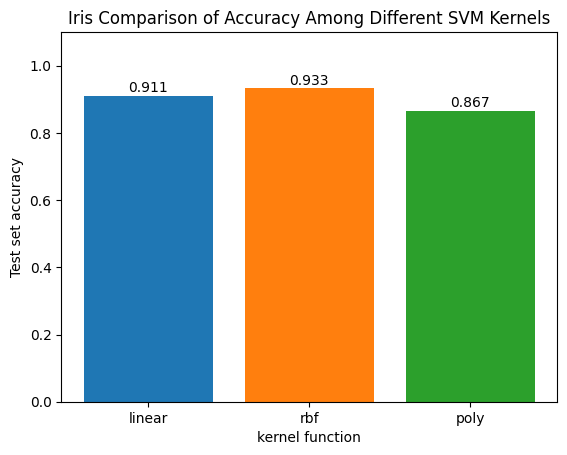

Wine - linear accuracy: 0.9630
Wine - rbf accuracy: 0.9815
Wine - poly accuracy: 0.9074


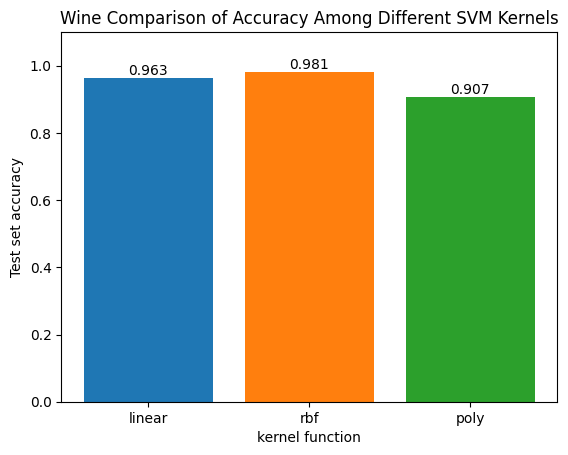

[0.9629629629629629, 0.9814814814814815, 0.9074074074074074]

In [18]:
def kernel_compare(X_train_scaled, X_test_scaled, y_train, y_test, name):
    kernels = ['linear', 'rbf', 'poly']
    accs = []
    
    for kernel in kernels:
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_train_scaled, y_train)
        y_pred = svm.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        accs.append(acc)
        print(f"{name} - {kernel} accuracy: {acc:.4f}")
    
    plt.bar(kernels, accs, color=['#1f77b4','#ff7f0e','#2ca02c'])
    plt.title(f'{name} Comparison of Accuracy Among Different SVM Kernels')
    plt.xlabel('kernel function')
    plt.ylabel('Test set accuracy')
    for i, v in enumerate(accs):
        plt.text(i, v+0.01, f'{v:.3f}', ha='center')
    plt.ylim(0, 1.1)
    plt.show()
    return accs

kernel_compare(X_iris_train_scaled, X_iris_test_scaled, y_iris_train, y_iris_test, "Iris")
kernel_compare(X_wine_train_scaled, X_wine_test_scaled, y_wine_train, y_wine_test, "Wine")

In [19]:
def svm_grid_search(X_train_scaled, y_train, name):
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [1, 0.1, 0.01, 0.001],
        'kernel': ['linear', 'rbf', 'poly']
    }
    
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, verbose=1)
    grid.fit(X_train_scaled, y_train)
    
    print(f"\n===== {name} Optimal parameters =====")
    print(f"Optimal parameters: {grid.best_params_}")
    print(f"Optimal cross-validation accuracy: {grid.best_score_:.4f}")
    return grid.best_estimator_

best_iris_svm = svm_grid_search(X_iris_train_scaled, y_iris_train, "Iris")
best_wine_svm = svm_grid_search(X_wine_train_scaled, y_wine_train, "Wine")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

===== Iris Optimal parameters =====
Optimal parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Optimal cross-validation accuracy: 0.9810
Fitting 5 folds for each of 48 candidates, totalling 240 fits

===== Wine Optimal parameters =====
Optimal parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Optimal cross-validation accuracy: 0.9920


In [20]:
def nested_cv(X_scaled, y, name):
    param_grid = {'C': [0.1,1,10], 'gamma': [0.1,0.01], 'kernel': ['linear','rbf']}
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5)

    nested_scores = cross_val_score(grid, X_scaled, y, cv=5)
    print(f"\n{name} Average accuracy of nested cross-validation: {nested_scores.mean():.4f}")
    return nested_scores.mean()

nested_cv(X_iris_train_scaled, y_iris_train, "Iris")
nested_cv(X_wine_train_scaled, y_wine_train, "Wine")


Iris Average accuracy of nested cross-validation: 0.9810

Wine Average accuracy of nested cross-validation: 0.9840


0.984

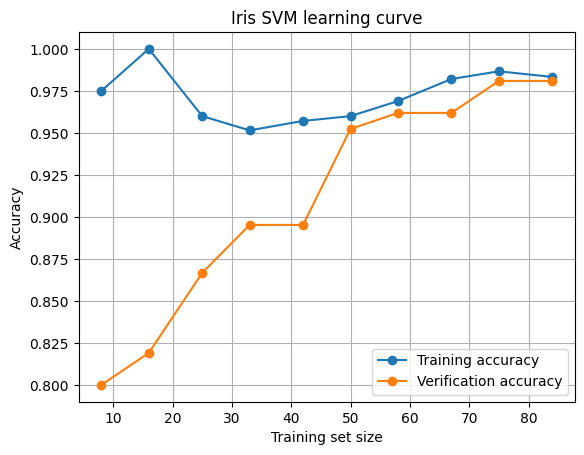

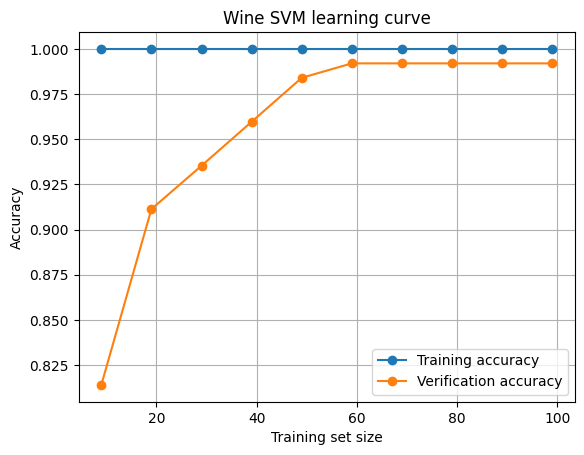

In [21]:
def plot_learning_curve(X_train_scaled, y_train, best_model, name):
    train_sizes, train_scores, val_scores = learning_curve(
        best_model, X_train_scaled, y_train, cv=5, train_sizes=np.linspace(0.1,1.0,10)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', label='Training accuracy')
    plt.plot(train_sizes, val_mean, 'o-', label='Verification accuracy')
    plt.title(f'{name} SVM learning curve')
    plt.xlabel('Training set size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(X_iris_train_scaled, y_iris_train, best_iris_svm, "Iris")
plot_learning_curve(X_wine_train_scaled, y_wine_train, best_wine_svm, "Wine")


===== Iris Test set evaluation =====
Accuracy: 0.9111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



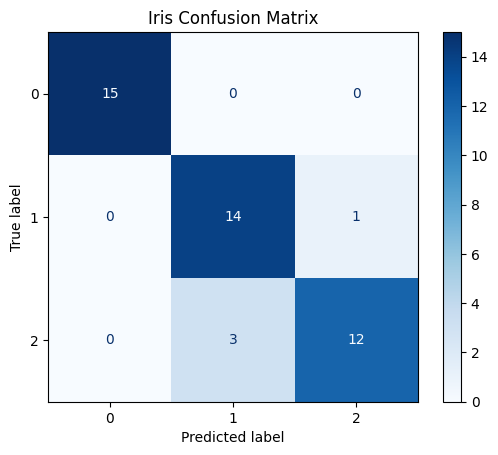


===== Wine Test set evaluation =====
Accuracy: 0.9815
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



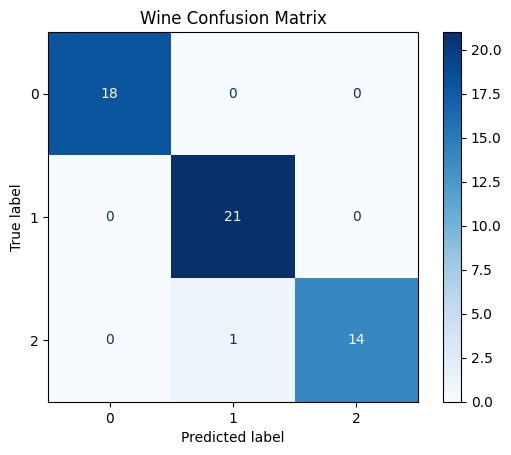

In [22]:

def evaluate_model(model, X_test_scaled, y_test, name):
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n===== {name} Test set evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

evaluate_model(best_iris_svm, X_iris_test_scaled, y_iris_test, "Iris")
evaluate_model(best_wine_svm, X_wine_test_scaled, y_wine_test, "Wine")

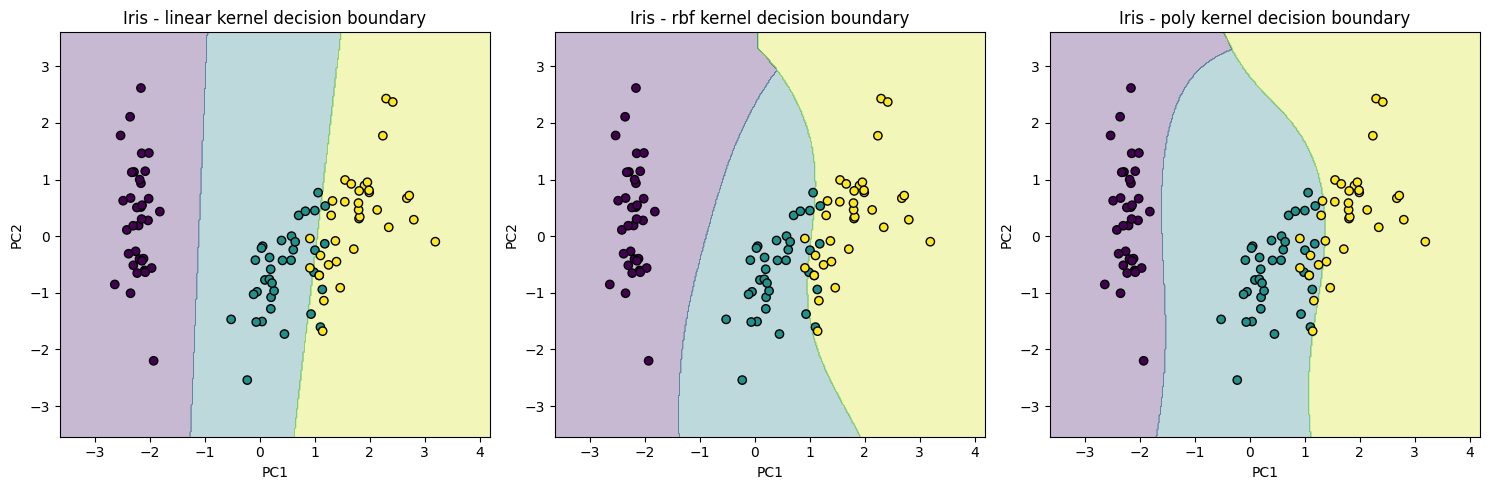

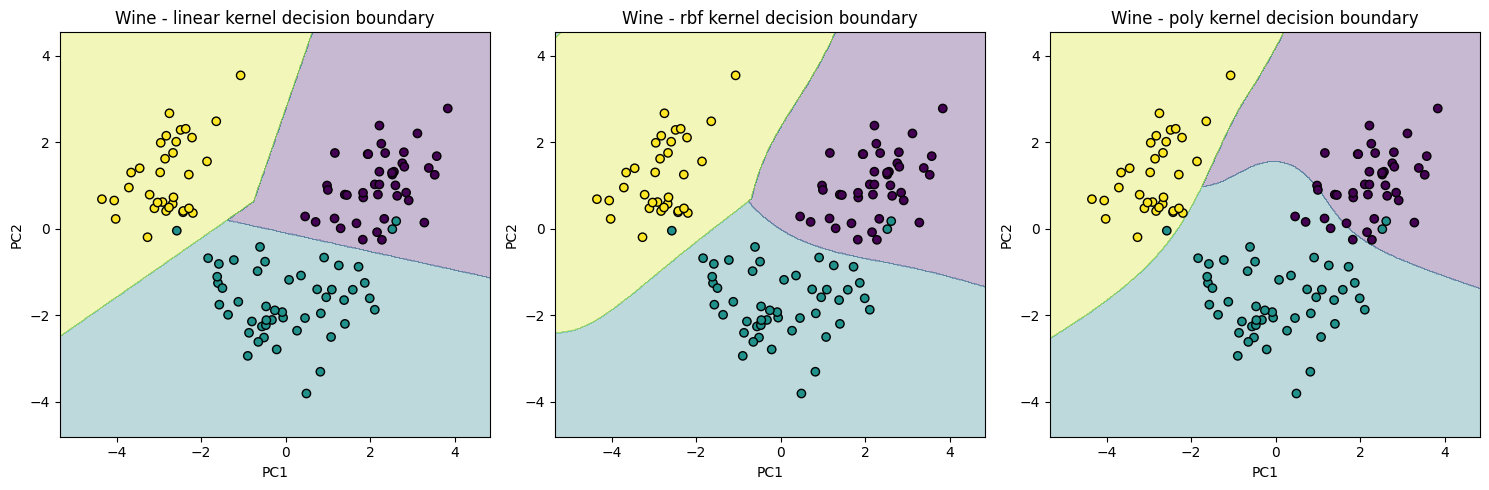

In [23]:
def plot_decision_boundary(X_train_scaled, y_train, name):
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    kernels = ['linear', 'rbf', 'poly']
    plt.figure(figsize=(15,5))
    
    for i, kernel in enumerate(kernels):
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_train_pca, y_train)
        
        x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
        y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.subplot(1,3,i+1)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
        plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', edgecolors='k')
        plt.title(f'{name} - {kernel} kernel decision boundary')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
    
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_iris_train_scaled, y_iris_train, "Iris")
plot_decision_boundary(X_wine_train_scaled, y_wine_train, "Wine")

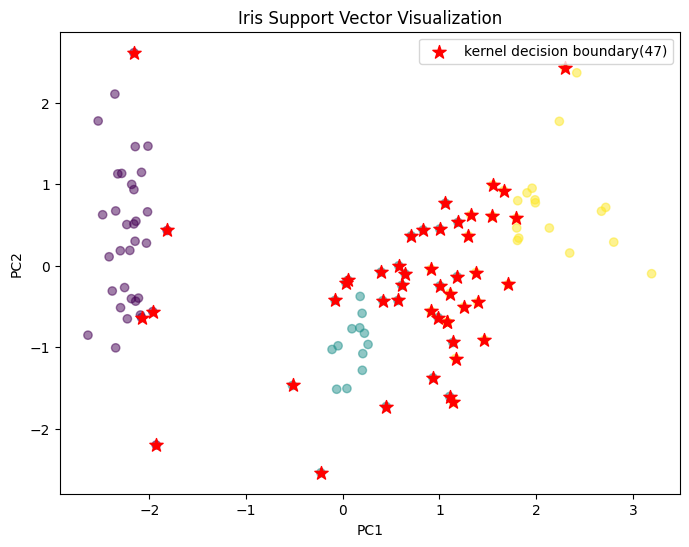

Iris Number of support vectors: 47


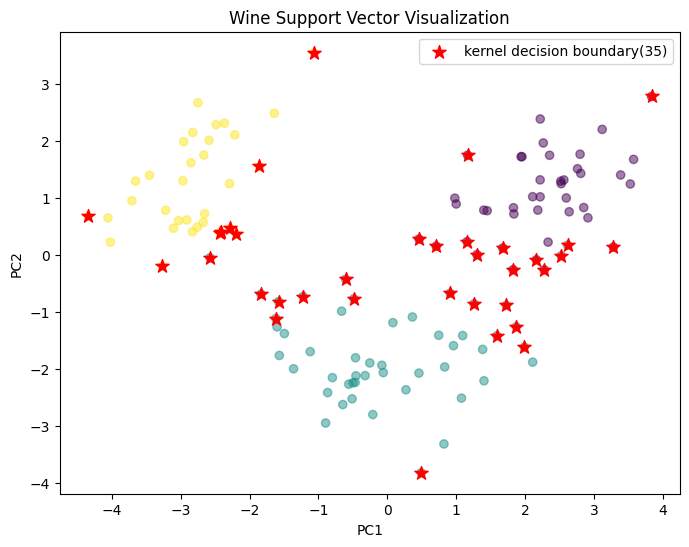

Wine Number of support vectors: 35


In [24]:
def plot_support_vectors(X_train_scaled, y_train, best_model, name):
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    best_model.fit(X_train_pca, y_train)
    
    sv_indices = best_model.support_
    sv_num = len(sv_indices)
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.5)
    plt.scatter(X_train_pca[sv_indices,0], X_train_pca[sv_indices,1], 
                c='red', s=100, marker='*', label=f'kernel decision boundary({sv_num})')
    plt.title(f'{name} Support Vector Visualization')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()
    print(f"{name} Number of support vectors: {sv_num}")

plot_support_vectors(X_iris_train_scaled, y_iris_train, best_iris_svm, "Iris")
plot_support_vectors(X_wine_train_scaled, y_wine_train, best_wine_svm, "Wine")

The Impact of Kernel Functions on Generalization and Boundaries
Linear Kernel: It generates linear boundaries, featuring simplicity and strong generalization ability, and is suitable for linearly separable data.
RBF Kernel: It produces smooth and curved boundaries with powerful fitting capability but a high risk of overfitting, and is applicable to nonlinear data.
Polynomial Kernel: It forms complex boundaries, and higher polynomial orders lead to a greater tendency of overfitting.

Core Issues of Support Vectors
Definition: Support vectors are critical samples that determine the decision boundary, referring to the points closest to the boundary.
Image Interpretation: The red star marks represent support vectors, which are the "key samples" of the model.
Quantity Impact: Fewer support vectors result in a simpler model with better generalization; more support vectors lead to a more complex model that is prone to overfitting.